# Feature-Enhanced NCF Stage 3

**Purpose:** Train and evaluate Stage 3 only.  
Stages 1 and 2 are already complete. This notebook rebuilds the required  
intermediate data and runs Stage 3 directly.

**Stage 3 adds on top of Stage 2:**
- User-item matching: `user_author_interaction_share_before_t`, `num_pages_preference_gap`, `user_profile_embedding_similarity`
- User history: `user_hist_interaction_count_before_t`, `user_hist_author_diversity_before_t`, `days_since_user_last_interaction`

**Fix vs previous version:** User-item matching features are now computed fresh  for each (user, item) pair including negative samples, rather than merging by  user_idx only. User history features are still merged by user_idx.

## 0. Imports

In [ ]:
import os
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from tqdm import tqdm

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from sklearn.preprocessing import LabelEncoder, StandardScaler
from google.colab import drive

drive.mount("/content/drive")
DATA_DIR = "/content/drive/My Drive/BT4222Project/"

SEED = 4222
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
K = 10
print(f"Device: {DEVICE}")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Device: cuda


## 1. Load Splits

In [ ]:
train_df = pd.read_pickle(DATA_DIR + "App1_train.pkl")
val_df = pd.read_pickle(DATA_DIR + "App1_val.pkl")
test_df = pd.read_pickle(DATA_DIR + "App1_test.pkl")

for df in [train_df, val_df, test_df]:
    df["user_id"] = df["user_id"].astype(str)
    df["book_id"] = df["book_id"].astype(str)
    df["event_time"] = pd.to_datetime(df["event_time"], errors="coerce")
    df.sort_values(["user_id", "event_time"], inplace=True)
    df.reset_index(drop=True, inplace=True)

print(f"Train : {len(train_df):,} rows  |  {train_df['user_id'].nunique():,} users")
print(f"Val   : {len(val_df):,} rows  |  {val_df['user_id'].nunique():,} users")
print(f"Test  : {len(test_df):,} rows  |  {test_df['user_id'].nunique():,} users")

Train : 6,017,121 rows  |  454,189 users
Val   : 1,317,799 rows  |  315,520 users
Test  : 1,435,444 rows  |  315,520 users


## 2. Label Encoding

In [ ]:
user_enc = LabelEncoder()
item_enc = LabelEncoder()

all_users = pd.concat([train_df, val_df, test_df])["user_id"].unique()
all_items = pd.concat([train_df, val_df, test_df])["book_id"].unique()
user_enc.fit(all_users)
item_enc.fit(all_items)

num_users = len(user_enc.classes_)
num_items = len(item_enc.classes_)

item_to_idx = {item: idx for idx, item in enumerate(item_enc.classes_)}
user_to_idx = {u: idx   for idx, u   in enumerate(user_enc.classes_)}

def encode_df(df):
    d = df[
        df["user_id"].isin(user_enc.classes_) &
        df["book_id"].isin(item_enc.classes_)
    ].copy()
    d["user_idx"] = user_enc.transform(d["user_id"])
    d["item_idx"] = item_enc.transform(d["book_id"])
    return d

train_enc = encode_df(train_df)
val_enc = encode_df(val_df)
test_enc = encode_df(test_df)

print(f"Users: {num_users:,}  Items: {num_items:,}")

Users: 454,189  Items: 123,087


## 3. Categorical Encoders

In [ ]:
format_enc = LabelEncoder()
lang_enc   = LabelEncoder()
author_enc = LabelEncoder()

all_formats = pd.concat([train_df, val_df, test_df])["format_collapsed"].fillna("unknown").unique()
all_langs = pd.concat([train_df, val_df, test_df])["language_code_collapsed"].fillna("unknown").unique()
all_authors = pd.concat([train_df, val_df, test_df])["main_author_id"].fillna("unknown").astype(str).unique()

format_enc.fit(all_formats)
lang_enc.fit(all_langs)
author_enc.fit(all_authors)

num_formats = len(format_enc.classes_)
num_langs = len(lang_enc.classes_)
num_authors = len(author_enc.classes_)

print(f"Formats: {num_formats}  Languages: {num_langs}  Authors: {num_authors}")

def encode_categoricals(df):
    d = df.copy()
    d["format_idx"] = format_enc.transform(d["format_collapsed"].fillna("unknown"))
    d["lang_idx"] = lang_enc.transform(d["language_code_collapsed"].fillna("unknown"))
    d["author_idx"] = author_enc.transform(d["main_author_id"].fillna("unknown").astype(str))
    return d

train_enc = encode_categoricals(train_enc)
val_enc   = encode_categoricals(val_enc)
test_enc  = encode_categoricals(test_enc)
print("Categorical encoding done.")

Formats: 11  Languages: 79  Authors: 24992
Categorical encoding done.


## 4. Numerical Feature Scaling

In [ ]:
NUMERICAL_COLS = [
    "num_pages", "publication_year",
    "book_interactions_count_before_t",
    "days_since_book_last_interaction",
    "author_interactions_count_before_t",
    "num_pages_preference_gap",
    "user_profile_embedding_similarity",
    "user_hist_interaction_count_before_t",
    "user_hist_author_diversity_before_t",
    "days_since_user_last_interaction",
    "user_author_interaction_share_before_t",
]
NUMERICAL_COLS = [c for c in NUMERICAL_COLS if c in train_enc.columns]
print(f"Scaling {len(NUMERICAL_COLS)} numerical columns")

scaler = StandardScaler()
train_enc[NUMERICAL_COLS] = scaler.fit_transform(train_enc[NUMERICAL_COLS].fillna(0))
val_enc[NUMERICAL_COLS] = scaler.transform(val_enc[NUMERICAL_COLS].fillna(0))
test_enc[NUMERICAL_COLS] = scaler.transform(test_enc[NUMERICAL_COLS].fillna(0))
print("Scaling done.")

Scaling 11 numerical columns
Scaling done.


## 5. Rebuild train_with_neg_s2

In [ ]:
STAGE1_EMB_COL  = "item_semantic_embedding_static"
STATIC_EMB_DIM  = 384
STAGE2_CAT_COLS = ["format_idx", "lang_idx", "author_idx"]
STAGE2_NUM_COLS = [
    "num_pages", "publication_year", "is_ebook",
    "book_interactions_count_before_t",
    "days_since_book_last_interaction",
    "author_interactions_count_before_t",
]
STAGE2_NUM_COLS = [c for c in STAGE2_NUM_COLS if c in train_enc.columns]

top_1000_books = (
    train_df.groupby("book_id").size()
    .sort_values(ascending=False)
    .head(1000).index.tolist()
)

user_full_history = (
    pd.concat([train_df, val_df, test_df])
    .groupby("user_id")["book_id"]
    .apply(set).to_dict()
)

pos = train_enc[["user_idx", "item_idx"]].copy()
pos["label"] = 1

neg_rows = []
for user_id, group in tqdm(train_enc.groupby("user_id"), desc="Sampling negatives"):
    seen = user_full_history.get(user_id, set())
    pool = [b for b in top_1000_books if b not in seen and b in item_to_idx]
    n = min(len(group), len(pool))
    if n == 0: continue
    sampled = random.sample(pool, n)
    uidx    = user_to_idx[user_id]
    neg_rows.append(pd.DataFrame({
        "user_idx": uidx,
        "item_idx": [item_to_idx[b] for b in sampled],
        "label"   : 0
    }))

neg = pd.concat(neg_rows, ignore_index=True)
train_with_neg = (
    pd.concat([pos, neg], ignore_index=True)
    .sample(frac=1, random_state=SEED)
    .reset_index(drop=True)
)
print(f"train_with_neg: {len(train_with_neg):,} rows")

# Add SBERT embedding
emb_lookup_dict = (
    train_enc[["item_idx", STAGE1_EMB_COL]]
    .drop_duplicates("item_idx")
    .set_index("item_idx")[STAGE1_EMB_COL]
    .to_dict()
)
train_with_neg_s1 = train_with_neg.copy()
train_with_neg_s1[STAGE1_EMB_COL] = train_with_neg_s1["item_idx"].map(
    emb_lookup_dict
).apply(lambda x: x if isinstance(x, np.ndarray)
        else np.zeros(STATIC_EMB_DIM, dtype=np.float32))

# Add Stage 2 item metadata features
train_with_neg_s2 = train_with_neg_s1.copy()
for col in STAGE2_NUM_COLS:
    num_lkp = (train_enc[["item_idx", col]]
               .drop_duplicates("item_idx")
               .set_index("item_idx")[col].to_dict())
    train_with_neg_s2[col] = (
        train_with_neg_s2["item_idx"].map(num_lkp)
        .pipe(pd.to_numeric, errors="coerce").fillna(0).astype(np.float32))

for col in STAGE2_CAT_COLS:
    cat_lkp = (train_enc[["item_idx", col]]
               .drop_duplicates("item_idx")
               .set_index("item_idx")[col].to_dict())
    train_with_neg_s2[col] = (
        train_with_neg_s2["item_idx"].map(cat_lkp).fillna(0).astype(int))

print(f"train_with_neg_s2: {len(train_with_neg_s2):,} rows")

Sampling negatives: 100%|██████████| 454189/454189 [03:33<00:00, 2127.12it/s]


train_with_neg: 11,789,793 rows
train_with_neg_s2: 11,789,793 rows


## 6. Dataset Class

In [ ]:
class FeatureNCFDataset(Dataset):
    def __init__(self, df, feature_cols=None, cat_cols=None, emb_col=None,
                 label_col="label"):
        self.users  = torch.tensor(df["user_idx"].values, dtype=torch.long)
        self.items  = torch.tensor(df["item_idx"].values, dtype=torch.long)
        self.labels = torch.tensor(df[label_col].values,  dtype=torch.float32)

        self.feature_cols = feature_cols or []
        self.cat_cols     = cat_cols     or []
        self.emb_col      = emb_col

        if self.feature_cols:
            self.num_feats = torch.tensor(
                df[self.feature_cols].values, dtype=torch.float32)
        if self.cat_cols:
            self.cat_feats = torch.tensor(
                df[self.cat_cols].values, dtype=torch.long)
        if self.emb_col:
            self.emb_feats = torch.tensor(
                np.vstack(df[self.emb_col].values), dtype=torch.float32)

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):
        batch = {
            "user":  self.users[idx],
            "item":  self.items[idx],
            "label": self.labels[idx],
        }
        if self.feature_cols:
            batch["num_feats"] = self.num_feats[idx]
        if self.cat_cols:
            batch["cat_feats"] = self.cat_feats[idx]
        if self.emb_col:
            batch["emb_feats"] = self.emb_feats[idx]
        return batch

print("FeatureNCFDataset defined.")

FeatureNCFDataset defined.


## 7. Feature-Enhanced NCF Model

In [ ]:
class FeatureEnhancedNCF(nn.Module):
    def __init__(self, num_users, num_items, embedding_dim=32,
                 num_formats=0, num_langs=0, num_authors=0, cat_emb_dim=8,
                 num_numerical=0, static_emb_dim=0, dropout=0.5):
        super().__init__()

        self.user_embedding = nn.Embedding(num_users, embedding_dim)
        self.item_embedding = nn.Embedding(num_items, embedding_dim)

        self.use_static_emb = static_emb_dim > 0
        self.use_cats       = num_formats > 0
        self.use_numerical  = num_numerical > 0

        if self.use_static_emb:
            self.static_proj = nn.Sequential(
                nn.Linear(static_emb_dim, embedding_dim), nn.ReLU())

        if self.use_cats:
            self.format_emb = nn.Embedding(num_formats + 1, cat_emb_dim, padding_idx=0)
            self.lang_emb   = nn.Embedding(num_langs   + 1, cat_emb_dim, padding_idx=0)
            self.author_emb = nn.Embedding(num_authors + 1, cat_emb_dim, padding_idx=0)

        cf_dim   = 2 * embedding_dim
        side_dim = 0
        if self.use_static_emb: side_dim += embedding_dim
        if self.use_cats:       side_dim += 3 * cat_emb_dim
        if self.use_numerical:  side_dim += num_numerical

        self.mlp = nn.Sequential(
            nn.Linear(cf_dim + side_dim, 256), nn.ReLU(),
            nn.Linear(256, 64), nn.BatchNorm1d(64),
            nn.ReLU(), nn.Dropout(dropout), nn.Linear(64, 1)
        )

    def forward(self, user, item, emb_feats=None, cat_feats=None, num_feats=None):
        x    = torch.cat([self.user_embedding(user), self.item_embedding(item)], dim=1)
        side = []
        if self.use_static_emb and emb_feats is not None:
            side.append(self.static_proj(emb_feats))
        if self.use_cats and cat_feats is not None:
            side.extend([self.format_emb(cat_feats[:, 0]),
                         self.lang_emb(cat_feats[:, 1]),
                         self.author_emb(cat_feats[:, 2])])
        if self.use_numerical and num_feats is not None:
            side.append(num_feats)
        if side:
            x = torch.cat([x] + side, dim=1)
        return self.mlp(x).squeeze(1)

print("FeatureEnhancedNCF defined.")

FeatureEnhancedNCF defined.


## 8. Training Function

In [ ]:
def train_stage(model, train_loader, val_loader, stage_name,
                num_epochs=10, patience=5, lr=0.001):
    criterion = nn.BCELoss()
    optimizer = optim.Adam(model.parameters(), lr=lr)
    best_loss, pc = float("inf"), 0
    train_losses, val_losses = [], []
    save_path = f"best_ncf_{stage_name}.pt"

    for epoch in range(num_epochs):
        model.train()
        epoch_loss = 0
        for batch in tqdm(train_loader,
                          desc=f"[{stage_name}] Epoch {epoch+1:02d}",
                          leave=False):
            user  = batch["user"].to(DEVICE)
            item  = batch["item"].to(DEVICE)
            label = batch["label"].to(DEVICE)
            emb   = batch["emb_feats"].to(DEVICE) if "emb_feats" in batch else None
            cat   = batch["cat_feats"].to(DEVICE) if "cat_feats" in batch else None
            num   = batch["num_feats"].to(DEVICE) if "num_feats" in batch else None
            optimizer.zero_grad()
            out  = torch.sigmoid(model(user, item, emb, cat, num))
            loss = criterion(out, label)
            loss.backward()
            optimizer.step()
            epoch_loss += loss.item()

        avg_train = epoch_loss / len(train_loader)
        train_losses.append(avg_train)

        model.eval()
        val_loss = 0
        with torch.no_grad():
            for batch in val_loader:
                user  = batch["user"].to(DEVICE)
                item  = batch["item"].to(DEVICE)
                label = batch["label"].to(DEVICE)
                emb   = batch["emb_feats"].to(DEVICE) if "emb_feats" in batch else None
                cat   = batch["cat_feats"].to(DEVICE) if "cat_feats" in batch else None
                num   = batch["num_feats"].to(DEVICE) if "num_feats" in batch else None
                out   = torch.sigmoid(model(user, item, emb, cat, num))
                val_loss += criterion(out, label).item()

        avg_val = val_loss / len(val_loader)
        val_losses.append(avg_val)
        print(f"  [{stage_name}] Epoch {epoch+1:02d}  Train: {avg_train:.4f}  Val: {avg_val:.4f}")

        if avg_val < best_loss:
            best_loss = avg_val; pc = 0
            torch.save(model.state_dict(), save_path)
            print(f"    Saved (val: {best_loss:.4f})")
        else:
            pc += 1
            if pc >= patience:
                print(f"  Early stopping at epoch {epoch+1}.")
                break

    plt.figure(figsize=(7, 3))
    plt.plot(train_losses, label="Train Loss")
    plt.title(f"{stage_name} — Train Loss Curve")
    plt.xlabel("Epoch"); plt.ylabel("BCE Loss")
    plt.legend(); plt.tight_layout(); plt.show()

    model.load_state_dict(torch.load(save_path, map_location=DEVICE))
    print(f"  Loaded best weights from {save_path}")
    return model

print("train_stage defined.")

train_stage defined.


## 9. Evaluation Function

In [ ]:
def hit_rate_at_k(preds, targets, k=10):
    top_k = np.argsort(-preds, axis=1)[:, :k]
    return np.mean([int(t in top) for t, top in zip(targets, top_k)])

def map_at_k(preds, targets, k=10):
    top_k = np.argsort(-preds, axis=1)[:, :k]
    ap_list = []
    for t, top in zip(targets, top_k):
        if t in top:
            rank = np.where(top == t)[0][0] + 1
            ap_list.append(1.0 / rank)
        else:
            ap_list.append(0.0)
    return np.mean(ap_list)

def ndcg_at_k_rank(preds, targets, k=10):
    top_k = np.argsort(-preds, axis=1)[:, :k]
    ndcg_list = []
    for t, top in zip(targets, top_k):
        if t in top:
            rank = np.where(top == t)[0][0] + 1
            ndcg_list.append(1.0 / np.log2(rank + 1))
        else:
            ndcg_list.append(0.0)
    return np.mean(ndcg_list)

def evaluate_stage(model, eval_users, user_train_seen,
                   item_to_idx, user_to_idx, stage_name,
                   test_enc_df=None, emb_col=None, cat_cols=None, num_cols=None,
                   EVAL_NEG_SAMPLES=999):
    model.eval()
    emb_lookup, cat_lookup, num_lookup = {}, {}, {}
    if test_enc_df is not None:
        item_rows = test_enc_df.drop_duplicates("item_idx").set_index("item_idx")
        if emb_col and emb_col in item_rows.columns:
            emb_lookup = item_rows[emb_col].to_dict()
        if cat_cols and all(c in item_rows.columns for c in cat_cols):
            cat_lookup = {idx: row[cat_cols].values.astype(int).tolist()
                          for idx, row in item_rows[cat_cols].iterrows()}
        if num_cols and all(c in item_rows.columns for c in num_cols):
            num_lookup = {idx: row[num_cols].values.astype(float).tolist()
                          for idx, row in item_rows[num_cols].iterrows()}

    EMB_DIM = 384
    n_cats  = len(cat_cols) if cat_cols else 0
    n_nums  = len(num_cols) if num_cols else 0
    all_preds_rank, all_targets_rank = [], []

    with torch.no_grad():
        for uid, true_books in tqdm(eval_users, desc=f"Evaluating {stage_name}"):
            uidx        = user_to_idx[uid]
            target_book = true_books[0]
            target_idx  = item_to_idx[target_book]

            seen     = user_train_seen.get(uid, set()) | set(true_books)
            neg_pool = [b for b in top_1000_books if b not in seen and b in item_to_idx]
            negs     = random.sample(neg_pool, min(EVAL_NEG_SAMPLES, len(neg_pool)))
            candidates    = [target_book] + negs
            candidate_idx = [item_to_idx[b] for b in candidates]
            n_cands       = len(candidate_idx)

            u_t = torch.tensor([uidx] * n_cands, dtype=torch.long).to(DEVICE)
            i_t = torch.tensor(candidate_idx,    dtype=torch.long).to(DEVICE)

            emb_t = None
            if emb_lookup:
                emb_arr = np.array([
                    emb_lookup.get(idx, np.zeros(EMB_DIM, dtype=np.float32))
                    for idx in candidate_idx], dtype=np.float32)
                emb_t = torch.tensor(emb_arr).to(DEVICE)

            cat_t = None
            if cat_lookup:
                cat_arr = np.array([
                    cat_lookup.get(idx, [0] * n_cats)
                    for idx in candidate_idx], dtype=np.int64)
                cat_t = torch.tensor(cat_arr).to(DEVICE)

            num_t = None
            if num_lookup:
                num_arr = np.array([
                    num_lookup.get(idx, [0.0] * n_nums)
                    for idx in candidate_idx], dtype=np.float32)
                num_t = torch.tensor(num_arr).to(DEVICE)

            scores = torch.sigmoid(
                model(u_t, i_t, emb_t, cat_t, num_t)
            ).cpu().numpy()

            score_vec = np.full(len(item_to_idx), -np.inf)
            for idx, score in zip(candidate_idx, scores):
                score_vec[idx] = score

            all_preds_rank.append(score_vec)
            all_targets_rank.append(target_idx)

    all_preds_rank   = np.array(all_preds_rank)
    all_targets_rank = np.array(all_targets_rank)

    hr   = hit_rate_at_k(all_preds_rank, all_targets_rank, k=K)
    mapk = map_at_k(all_preds_rank,      all_targets_rank, k=K)
    ndcg = ndcg_at_k_rank(all_preds_rank, all_targets_rank, k=K)

    print(f"\n  {stage_name} — Results (K={K}, {len(all_targets_rank):,} users)")
    print(f"  HR@{K}  : {hr:.4f}")
    print(f"  MAP@{K} : {mapk:.4f}")
    print(f"  nDCG@{K}: {ndcg:.4f}")
    return {f"HR@{K}": hr, f"MAP@{K}": mapk, f"nDCG@{K}": ndcg}, all_preds_rank, all_targets_rank

print("Evaluation functions defined.")

Evaluation functions defined.


## 10. Load Evaluation Users

In [ ]:
sampled_user_ids = pd.read_csv(DATA_DIR + "eval_sample_users.csv").iloc[:, 0].tolist()
print(f"Loaded {len(sampled_user_ids):,} sampled evaluation users")

user_train_seen     = train_df.groupby("user_id")["book_id"].apply(set).to_dict()
true_items_per_user = test_df.groupby("user_id")["book_id"].apply(list).to_dict()

eval_users = [
    (uid, [b for b in true_items_per_user[uid] if b in item_to_idx])
    for uid in sampled_user_ids
    if uid in true_items_per_user and uid in user_to_idx
]
eval_users = [(uid, books) for uid, books in eval_users if books]
print(f"Evaluating on {len(eval_users):,} users")

Loaded 5,000 sampled evaluation users
Evaluating on 5,000 users


## 11. Stage 3 — + User-Item Matching + User History

**User-item matching features** (`user_profile_embedding_similarity`,  
`num_pages_preference_gap`, `user_author_interaction_share_before_t`) are  
computed fresh for each (user, item) pair including negative samples:
- `num_pages_preference_gap` = |item num_pages - user average num_pages from training history|
- `user_profile_embedding_similarity` = cosine similarity between item SBERT embedding and user average embedding from training history
- `user_author_interaction_share_before_t` = proportion of user training interactions sharing the same author as the item

**User history features** (`user_hist_*`, `days_since_user_last_interaction`)  
are merged by user_idx — correct, as they do not depend on the item.

In [ ]:
STAGE3_NUM_COLS = STAGE2_NUM_COLS + [
    "user_author_interaction_share_before_t",
    "num_pages_preference_gap",
    "user_profile_embedding_similarity",
    "user_hist_interaction_count_before_t",
    "user_hist_author_diversity_before_t",
    "days_since_user_last_interaction",
]
STAGE3_NUM_COLS = [c for c in STAGE3_NUM_COLS if c in train_enc.columns]
print(f"Stage 3 numerical features ({len(STAGE3_NUM_COLS)}): {STAGE3_NUM_COLS}")

USER_LEVEL_COLS = [
    "user_hist_interaction_count_before_t",
    "user_hist_author_diversity_before_t",
    "days_since_user_last_interaction",
]
USER_LEVEL_COLS = [c for c in USER_LEVEL_COLS if c in train_enc.columns]

USER_ITEM_COLS = [
    "num_pages_preference_gap",
    "user_profile_embedding_similarity",
    "user_author_interaction_share_before_t",
]

user_level_features = (
    train_enc.groupby("user_idx")[USER_LEVEL_COLS]
    .last().reset_index().fillna(0)
)

#Precompute user-level signals
print("Precomputing user average page preference...")
user_avg_pages = train_enc.groupby("user_idx")["num_pages"].mean().to_dict()

print("Precomputing user profile embeddings...")
user_avg_emb = {
    uidx: np.mean(np.vstack(group["item_semantic_embedding_static"].values), axis=0)
    for uidx, group in tqdm(train_enc.groupby("user_idx"), desc="User embeddings")
}

print("Precomputing user author interaction shares...")
user_author_counts = (
    train_enc.groupby(["user_idx", "author_idx"]).size().reset_index(name="n")
)
user_total_counts = train_enc.groupby("user_idx").size().to_dict()
user_author_share = {
    (r.user_idx, r.author_idx): r.n / user_total_counts.get(r.user_idx, 1)
    for r in user_author_counts.itertuples()
}

# Item-level lookups
item_rows_lookup = train_enc.drop_duplicates("item_idx").set_index("item_idx")
item_pages_lookup = item_rows_lookup["num_pages"].to_dict()
item_pages_lookup_raw = (
    train_df.merge(train_enc[["user_id", "book_id", "item_idx"]].drop_duplicates("item_idx"),
                   on=["user_id", "book_id"])
    .drop_duplicates("item_idx")
    .set_index("item_idx")["num_pages"]
    .to_dict()
)

user_avg_pages_raw = (
    train_df.merge(train_enc[["user_id", "user_idx"]].drop_duplicates("user_idx"),
                   on="user_id")
    .groupby("user_idx")["num_pages"]
    .mean().to_dict()
)
item_emb_lookup = item_rows_lookup["item_semantic_embedding_static"].to_dict()
item_author_lookup = item_rows_lookup["author_idx"].to_dict()

CHUNK = 500_000
# Build page lookup from RAW unscaled data

def compute_user_item_features(df, uidx_col="user_idx", iidx_col="item_idx"):
    """Compute user-item matching features for any dataframe."""
    df = df.copy()

    # num_pages_preference_gap
    item_pages = df[iidx_col].map(item_pages_lookup_raw).fillna(0)
    user_pages = df[uidx_col].map(user_avg_pages_raw).fillna(item_pages)
    df["num_pages_preference_gap"] = (item_pages - user_pages).abs().astype(np.float32)

    # user_author_interaction_share
    item_author = df[iidx_col].map(item_author_lookup).fillna(-1).astype(int)
    auth_idx  = pd.MultiIndex.from_arrays([
        df[uidx_col].astype(int).values,
        item_author.values
    ])
    df["user_author_interaction_share_before_t"] = (
        auth_idx.map(user_author_share).fillna(0.0).astype(np.float32)
    )

    # user_profile_embedding_similarity — chunked
    uidxs = df[uidx_col].values
    iidxs = df[iidx_col].values
    sims  = np.zeros(len(df), dtype=np.float32)
    for start in range(0, len(df), CHUNK):
        end = min(start + CHUNK, len(df))
        u_chunk = np.vstack([user_avg_emb.get(int(u), np.zeros(384, dtype=np.float32)) for u in uidxs[start:end]])
        i_chunk = np.vstack([item_emb_lookup.get(int(i), np.zeros(384, dtype=np.float32)) for i in iidxs[start:end]])
        u_norms = np.linalg.norm(u_chunk, axis=1,keepdims=True).clip(min=1e-8)
        i_norms = np.linalg.norm(i_chunk, axis=1, keepdims=True).clip(min=1e-8)
        sims[start:end] = (u_chunk / u_norms * i_chunk / i_norms).sum(axis=1)
    df["user_profile_embedding_similarity"] = sims

    return df

# Build train_with_neg_s3
print("Computing user-item matching features for train...")
train_with_neg_s3 = compute_user_item_features(train_with_neg_s2)

train_with_neg_s3["user_idx"] = train_with_neg_s3["user_idx"].astype(int)
user_level_features["user_idx"] = user_level_features["user_idx"].astype(int)
train_with_neg_s3 = train_with_neg_s3.merge(
    user_level_features[["user_idx"] + USER_LEVEL_COLS],
    on="user_idx", how="left"
)
for col in STAGE3_NUM_COLS:
    if col in train_with_neg_s3.columns:
        train_with_neg_s3[col] = (
            pd.to_numeric(train_with_neg_s3[col], errors="coerce")
            .fillna(0).astype(np.float32)
        )
    else:
        train_with_neg_s3[col] = np.float32(0.0)
# Build val positives
print("Computing user-item matching features for val positives...")
val_pos = compute_user_item_features(val_enc)
val_pos["user_idx"] = val_pos["user_idx"].astype(int)
val_pos = val_pos.merge(
    user_level_features[["user_idx"] + USER_LEVEL_COLS],
    on="user_idx", how="left"
)
val_pos["label"] = 1

# Val — positives only (consistent with Stages 1 and 2)
val_enc_s3 = val_pos.copy()
for col in STAGE3_NUM_COLS:
    if col in val_enc_s3.columns:
        val_enc_s3[col] = (
            pd.to_numeric(val_enc_s3[col], errors="coerce")
            .fillna(0).astype(np.float32)
        )
    else:
        val_enc_s3[col] = np.float32(0.0)
val_enc_s3["label"] = 1
print(f"Val rows: {len(val_enc_s3):,}")
print(val_enc_s3["label"].value_counts())

# Rescale user-item matching features
scaler_s3 = StandardScaler()
train_with_neg_s3[USER_ITEM_COLS] = scaler_s3.fit_transform(
    train_with_neg_s3[USER_ITEM_COLS].fillna(0)
)
val_enc_s3[USER_ITEM_COLS] = scaler_s3.transform(
    val_enc_s3[USER_ITEM_COLS].fillna(0)
)
print("User-item matching features rescaled.")

# Dataloaders
train_loader_s3 = DataLoader(
    FeatureNCFDataset(train_with_neg_s3,
                      emb_col=STAGE1_EMB_COL,
                      cat_cols=STAGE2_CAT_COLS,
                      feature_cols=STAGE3_NUM_COLS),
    batch_size=2048, shuffle=True, num_workers=2, pin_memory=True)

val_loader_s3 = DataLoader(
    FeatureNCFDataset(val_enc_s3,
                      emb_col=STAGE1_EMB_COL,
                      cat_cols=STAGE2_CAT_COLS,
                      feature_cols=STAGE3_NUM_COLS),
    batch_size=2048, shuffle=False, num_workers=2, pin_memory=True)

print(f"\ntrain_with_neg_s3 : {len(train_with_neg_s3):,} rows")
print(f"val_enc_s3        : {len(val_enc_s3):,} rows")
print(f"Train batches     : {len(train_loader_s3)}")
print(f"Val   batches     : {len(val_loader_s3)}")

Stage 3 numerical features (12): ['num_pages', 'publication_year', 'is_ebook', 'book_interactions_count_before_t', 'days_since_book_last_interaction', 'author_interactions_count_before_t', 'user_author_interaction_share_before_t', 'num_pages_preference_gap', 'user_profile_embedding_similarity', 'user_hist_interaction_count_before_t', 'user_hist_author_diversity_before_t', 'days_since_user_last_interaction']
Precomputing user average page preference...
Precomputing user profile embeddings...


User embeddings: 100%|██████████| 454189/454189 [01:14<00:00, 6121.25it/s]


Precomputing user author interaction shares...
Computing user-item matching features for train...
Computing user-item matching features for val positives...
Val rows: 1,317,799
label
1    1317799
Name: count, dtype: int64
User-item matching features rescaled.

train_with_neg_s3 : 11,789,793 rows
val_enc_s3        : 1,317,799 rows
Train batches     : 5757
Val   batches     : 644


## 12. Train Stage 3

Stage 3 converges significantly faster than earlier stages due to the additional user-item matching features, causing val BCE loss to rise from epoch 1 onward (Hence val BCE loss is ignored in Stage 3 as it is a misleading factor). Early stopping would save epoch 1 weights before the model has fully learned the Stage 3 features. Training for a fixed number of epochs and saving the final weights allows the model to complete its learning trajectory.

Total trainable parameters: 18,736,521
MLP input dim: 132
Training Stage 3 (fixed 5 epochs, no early stopping)...


Epoch 01  Train: 0.1008


Epoch 02  Train: 0.0725


Epoch 03  Train: 0.0684


Epoch 04  Train: 0.0658


Epoch 05  Train: 0.0636
Saved final epoch weights.


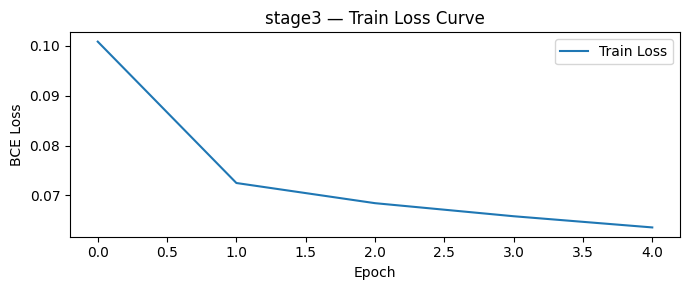

In [ ]:
#Fixed epoch training without early stopping

model_s3 = FeatureEnhancedNCF(
    num_users, num_items,
    static_emb_dim=STATIC_EMB_DIM,
    num_formats=num_formats, num_langs=num_langs, num_authors=num_authors,
    num_numerical=len(STAGE3_NUM_COLS)
).to(DEVICE)

total_params = sum(p.numel() for p in model_s3.parameters() if p.requires_grad)
print(f"Total trainable parameters: {total_params:,}")
print(f"MLP input dim: {model_s3.mlp[0].in_features}")
print("Training Stage 3 (fixed 5 epochs, no early stopping)...")

criterion  = nn.BCELoss()
optimizer  = optim.Adam(model_s3.parameters(), lr=0.001)
train_losses = []

for epoch in range(5):
    model_s3.train()
    epoch_loss = 0
    for batch in tqdm(train_loader_s3, desc=f"Epoch {epoch+1:02d}", leave=False):
        user  = batch["user"].to(DEVICE)
        item  = batch["item"].to(DEVICE)
        label = batch["label"].to(DEVICE)
        emb   = batch["emb_feats"].to(DEVICE) if "emb_feats" in batch else None
        cat   = batch["cat_feats"].to(DEVICE) if "cat_feats" in batch else None
        num   = batch["num_feats"].to(DEVICE) if "num_feats" in batch else None
        optimizer.zero_grad()
        out  = torch.sigmoid(model_s3(user, item, emb, cat, num))
        loss = criterion(out, label)
        loss.backward()
        optimizer.step()
        epoch_loss += loss.item()
    avg_train = epoch_loss / len(train_loader_s3)
    train_losses.append(avg_train)
    print(f"Epoch {epoch+1:02d}  Train: {avg_train:.4f}")

torch.save(model_s3.state_dict(), "best_ncf_stage3.pt")
print("Saved final epoch weights.")

plt.figure(figsize=(7, 3))
plt.plot(train_losses, label="Train Loss")
plt.title("stage3 — Train Loss Curve")
plt.xlabel("Epoch"); plt.ylabel("BCE Loss")
plt.legend(); plt.tight_layout(); plt.show()

## 13. Evaluate Stage 3

In [ ]:
import warnings
warnings.filterwarnings("ignore", category=UserWarning)
model_s3.load_state_dict(torch.load("best_ncf_stage3.pt", map_location=DEVICE))
model_s3.eval()

all_preds_rank, all_targets_rank = [], []

with torch.no_grad():
    for uid, true_books in tqdm(eval_users, desc="Evaluating Stage 3"):
        uidx = user_to_idx[uid]
        target_book = true_books[0]
        target_idx  = item_to_idx[target_book]

        seen  = user_train_seen.get(uid, set()) | set(true_books)
        neg_pool = [b for b in top_1000_books if b not in seen and b in item_to_idx]
        negs  = random.sample(neg_pool, min(999, len(neg_pool)))
        candidates  = [target_book] + negs
        candidate_idx = [item_to_idx[b] for b in candidates]
        n_cands       = len(candidate_idx)

        # Static item features (same for all users)
        emb_arr = np.array([
            item_emb_lookup.get(idx, np.zeros(384, dtype=np.float32))
            for idx in candidate_idx], dtype=np.float32)

        cat_arr = np.array([
            [item_rows_lookup.loc[idx, "format_idx"] if idx in item_rows_lookup.index else 0,
             item_rows_lookup.loc[idx, "lang_idx"]   if idx in item_rows_lookup.index else 0,
             item_rows_lookup.loc[idx, "author_idx"] if idx in item_rows_lookup.index else 0]
            for idx in candidate_idx], dtype=np.int64)

        # Stage 2 numerical features (item-level only)
        stage2_arr = np.array([
            [item_rows_lookup.loc[idx, c] if idx in item_rows_lookup.index else 0.0
             for c in STAGE2_NUM_COLS]
            for idx in candidate_idx], dtype=np.float32)

        #User-item matching features (computed per user-candidate pair)
        u_emb   = user_avg_emb.get(uidx, np.zeros(384, dtype=np.float32))
        u_pages = user_avg_pages.get(uidx, 0.0)

        pages_gaps, emb_sims, auth_shares = [], [], []
        for cidx in candidate_idx:
            # num_pages_preference_gap
            i_pages = item_pages_lookup_raw.get(cidx, 0.0)
            u_pages = user_avg_pages_raw.get(uidx, 0.0)
            pages_gaps.append(abs(i_pages - u_pages))

            # user_profile_embedding_similarity
            i_emb  = item_emb_lookup.get(cidx, np.zeros(384, dtype=np.float32))
            u_norm = np.linalg.norm(u_emb)
            i_norm = np.linalg.norm(i_emb)
            sim = float(np.dot(u_emb, i_emb) / (u_norm * i_norm)) if u_norm > 0 and i_norm > 0 else 0.0
            emb_sims.append(sim)

            # user_author_interaction_share_before_t
            a_idx  = item_author_lookup.get(cidx, -1)
            auth_shares.append(user_author_share.get((uidx, a_idx), 0.0))

        # user-level features (same for all candidates)
        u_level = user_level_features[
            user_level_features["user_idx"] == uidx
        ][USER_LEVEL_COLS].values
        u_level = u_level[0] if len(u_level) > 0 else np.zeros(len(USER_LEVEL_COLS))

        # Stack all numerical features in STAGE3_NUM_COLS order
        user_item_raw = np.array([
            [pages_gaps[i], emb_sims[i], auth_shares[i]]
            for i in range(n_cands)
        ], dtype=np.float32)
        user_item_scaled = scaler_s3.transform(user_item_raw)

        num_arr = np.concatenate([
            stage2_arr,
            user_item_scaled,
            np.tile(u_level, (n_cands, 1))
        ], axis=1).astype(np.float32)

        # Score candidates
        u_t   = torch.tensor([uidx] * n_cands, dtype=torch.long).to(DEVICE)
        i_t   = torch.tensor(candidate_idx, dtype=torch.long).to(DEVICE)
        emb_t = torch.tensor(emb_arr,  dtype=torch.float32).to(DEVICE)
        cat_t = torch.tensor(cat_arr, dtype=torch.long).to(DEVICE)
        num_t = torch.tensor(num_arr,  dtype=torch.float32).to(DEVICE)

        scores = torch.sigmoid(
            model_s3(u_t, i_t, emb_t, cat_t, num_t)
        ).cpu().numpy()

        score_vec = np.full(len(item_to_idx), -np.inf)
        for idx, score in zip(candidate_idx, scores):
            score_vec[idx] = score

        all_preds_rank.append(score_vec)
        all_targets_rank.append(target_idx)

all_preds_rank = np.array(all_preds_rank)
all_targets_rank = np.array(all_targets_rank)

hr   = hit_rate_at_k(all_preds_rank, all_targets_rank, k=K)
mapk = map_at_k(all_preds_rank,      all_targets_rank, k=K)
ndcg = ndcg_at_k_rank(all_preds_rank, all_targets_rank, k=K)

results_s3 = {f"HR@{K}": hr, f"MAP@{K}": mapk, f"nDCG@{K}": ndcg}

print(f"\n  Stage 3 - Results (K={K}, {len(all_targets_rank):,} users)")
print(f"  HR@{K}  : {hr:.4f}")
print(f"  MAP@{K} : {mapk:.4f}")
print(f"  nDCG@{K}: {ndcg:.4f}")

Evaluating Stage 3: 100%|██████████| 5000/5000 [06:53<00:00, 12.08it/s]



  Stage 3 - Results (K=10, 5,000 users)
  HR@10  : 0.2300
  MAP@10 : 0.1748
  nDCG@10: 0.1879


## 14. Results Summary

  Feature-Enhanced NCF — Ablation Results Summary
                           HR@10  MAP@10  nDCG@10
ID-only NCF               0.5312  0.4476   0.4670
Stage 1 (+ SBERT)         0.5256  0.4439   0.4629
Stage 2 (+ metadata)      0.4594  0.3774   0.3966
Stage 3 (+ user signals)  0.2300  0.1748   0.1879


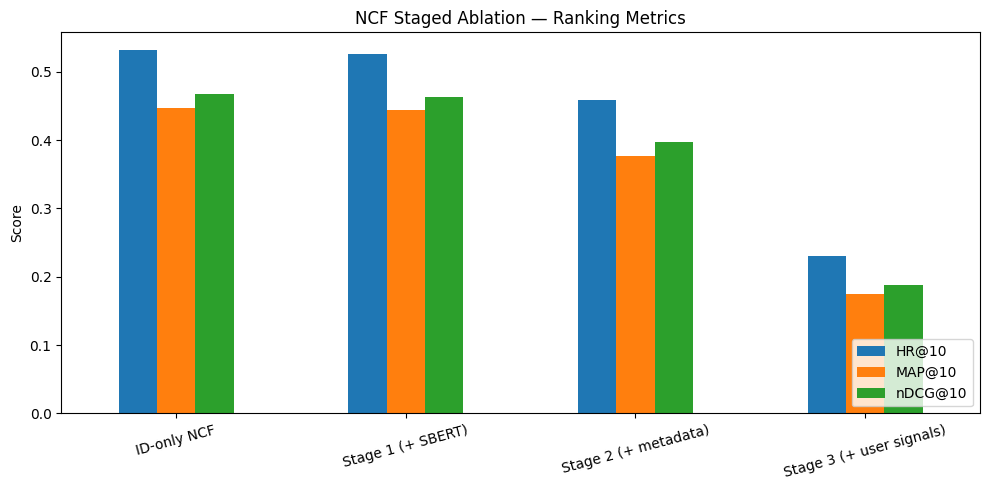

In [ ]:
# Results from previous notebooks
results_s1 = {f"HR@{K}": 0.5256, f"MAP@{K}": 0.4439, f"nDCG@{K}": 0.4629}
results_s2 = {f"HR@{K}": 0.4594, f"MAP@{K}": 0.3774, f"nDCG@{K}": 0.3966}
baseline   = {f"HR@{K}": 0.5312, f"MAP@{K}": 0.4476, f"nDCG@{K}": 0.4670}

summary = pd.DataFrame({
    "ID-only NCF":              baseline,
    "Stage 1 (+ SBERT)":        results_s1,
    "Stage 2 (+ metadata)":     results_s2,
    "Stage 3 (+ user signals)": results_s3,
}).T.round(4)

print("=" * 60)
print("  Feature-Enhanced NCF — Ablation Results Summary")
print("=" * 60)
print(summary.to_string())

summary.plot(kind="bar", figsize=(10, 5))
plt.title("NCF Staged Ablation — Ranking Metrics")
plt.ylabel("Score"); plt.xticks(rotation=15)
plt.legend(loc="lower right")
plt.tight_layout(); plt.show()

In [ ]:
# Segment analysis for Stage 3
user_train_counts_s3 = train_df.groupby("user_id").size()

def activity_bucket_3way(n):
    if 1 <= n <= 5:
        return "Low (1-5)"
    elif 6 <= n <= 38:
        return "Medium (6-38)"
    else:
        return "High (39+)"

# results_s3 evaluation stored all_preds_rank and all_targets_rank
# Re-run evaluate_stage with return_arrays=True or use the stored arrays
# Note: eval_users is list of (uid, books) tuples from Section 10
eval_user_ids_s3 = [uid for uid, _ in eval_users]

seg_results_s3 = {}

for seg_name in ["Low (1-5)", "Medium (6-38)", "High (39+)", "All"]:
    seg_preds, seg_targets = [], []

    for idx, uid in enumerate(eval_user_ids_s3):
        n_train = int(user_train_counts_s3.get(uid, 0))
        bucket  = activity_bucket_3way(n_train)

        if seg_name != "All" and bucket != seg_name:
            continue
        if idx >= len(all_preds_rank):
            continue

        seg_preds.append(all_preds_rank[idx])
        seg_targets.append(all_targets_rank[idx])

    if not seg_preds:
        print(f"\n{seg_name}: no users found")
        continue

    seg_preds_arr = np.array(seg_preds)
    seg_targets_arr = np.array(seg_targets)

    hr   = hit_rate_at_k(seg_preds_arr, seg_targets_arr, k=K)
    mapk = map_at_k(seg_preds_arr, seg_targets_arr, k=K)
    ndcg = ndcg_at_k_rank(seg_preds_arr, seg_targets_arr, k=K)

    seg_results_s3[seg_name] = {
        "n_users":  len(seg_targets_arr),
        f"HR@{K}":  round(hr, 4),
        f"MAP@{K}": round(mapk, 4),
        f"nDCG@{K}": round(ndcg, 4),
    }

    print(f"\n{seg_name} ({len(seg_targets_arr):,} users)")
    print(f"  HR@{K}: {hr:.4f}  MAP@{K}: {mapk:.4f}  nDCG@{K}: {ndcg:.4f}")

seg_df_s3 = pd.DataFrame(seg_results_s3).T
print("\nSummary table:")
print(seg_df_s3.to_string())


Low (1-5) (2,337 users)
  HR@10: 0.1990  MAP@10: 0.1369  nDCG@10: 0.1517

Medium (6-38) (2,144 users)
  HR@10: 0.2425  MAP@10: 0.1885  nDCG@10: 0.2014

High (39+) (519 users)
  HR@10: 0.3179  MAP@10: 0.2884  nDCG@10: 0.2954

All (5,000 users)
  HR@10: 0.2300  MAP@10: 0.1748  nDCG@10: 0.1879

Summary table:
               n_users   HR@10  MAP@10  nDCG@10
Low (1-5)       2337.0  0.1990  0.1369   0.1517
Medium (6-38)   2144.0  0.2425  0.1885   0.2014
High (39+)       519.0  0.3179  0.2884   0.2954
All             5000.0  0.2300  0.1748   0.1879
